In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-factitial-dermatitis-1.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/v-eczema-areola-13.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-eczema-subacute-66.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-eczema-hand-86.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-keratolysis-exfoliativa-17.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-lichen-simplex-chronicus-136.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-eczema-subacute-60.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-fissure-11.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-Dyshidrosis-36.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-Dyshidrosis-55.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-eczema-subacute-40.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/t-fissure-10.jpg
/kaggle/input/ending/IMG_CLASSES 11/1. Eczema 1677/v-iododerma-1.jpg
/kaggle/input/ending/IMG_CL

In [2]:
import tensorflow as tf
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


2025-10-05 07:06:57.086215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759648017.271009     818 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759648017.324412     818 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
DATASET_DIR = "/kaggle/input/ending/IMG_CLASSES 11"  
IMG_SIZE = (256, 256)
BATCH_SIZE = 16
AUTOTUNE = tf.data.AUTOTUNE

In [4]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Get class names
class_names = train_ds.class_names
print("Classes:", class_names)


Found 31906 files belonging to 12 classes.
Using 25525 files for training.


I0000 00:00:1759648027.195951     818 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Found 31906 files belonging to 12 classes.
Using 6381 files for validation.
Classes: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '11. Acne 2.5k', '12. Vitiligo 2191', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [5]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)


In [6]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])


In [7]:
base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    input_shape=IMG_SIZE + (3,),
    weights="imagenet"
)
base_model.trainable = False  # Freeze for Phase 1

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [8]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),  # lower LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [9]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

def get_class_weights(train_ds):
    
    print("🔢 Computing class weights from training dataset...")
    class_counts = []

    # Iterate lazily through dataset to collect labels only
    for _, labels in train_ds.unbatch():
        class_counts.append(int(labels.numpy()))

    class_counts = np.array(class_counts)
    classes = np.unique(class_counts)

    # Compute balanced weights
    weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=class_counts
    )

    class_weights = dict(zip(classes, weights))
    print("✅ Computed Class Weights:", class_weights)
    return class_weights
class_weights = get_class_weights(train_ds)


🔢 Computing class weights from training dataset...
✅ Computed Class Weights: {0: 1.551483102358376, 1: 1.259374383264259, 2: 1.0457636840380202, 3: 1.2154761904761904, 4: 0.842743000528262, 5: 2.0894728225278323, 6: 0.8017652971478829, 7: 0.33667035981850796, 8: 1.2616152629497825, 9: 1.3073652939971316, 10: 1.4208973502560678, 11: 1.5663352970054}


In [10]:
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=2)
    ]
)

Epoch 1/10


E0000 00:00:1759648123.423257     818 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1759648151.865800     860 cuda_dnn.cc:529] Loaded cuDNN version 90300


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 126s 52ms/step - accuracy: 0.4922 - loss: 1.5946 - val_accuracy: 0.6576 - val_loss: 0.9831 - learning_rate: 0.0010
Epoch 2/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6175 - loss: 1.1922 - val_accuracy: 0.6604 - val_loss: 0.9454 - learning_rate: 0.0010
Epoch 3/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6293 - loss: 1.1429 - val_accuracy: 0.6841 - val_loss: 0.8829 - learning_rate: 0.0010
Epoch 4/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6479 - loss: 1.1157 - val_accuracy: 0.6921 - val_loss: 0.8648 - learning_rate: 0.0010
Epoch 5/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6446 - loss: 1.1212 - val_accuracy: 0.6816 - val_loss: 0.8913 - learning_rate: 0.0010
Epoch 6/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6487 - loss: 1.0895 - val_accuracy: 0.6874 - val_loss: 0.8607 - learning_rate: 0.0010
Epoch 7/10
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 97s 45ms/step - accuracy: 0.6569

In [11]:
base_model.trainable = True
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # smaller LR
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    class_weight=class_weights,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]
)


Epoch 1/30


E0000 00:00:1759649163.449192     818 meta_optimizer.cc:966] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/functional_1_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


1596/1596 ━━━━━━━━━━━━━━━━━━━━ 395s 194ms/step - accuracy: 0.3717 - loss: 1.9949 - val_accuracy: 0.5767 - val_loss: 1.1608
Epoch 2/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 330s 191ms/step - accuracy: 0.5589 - loss: 1.3806 - val_accuracy: 0.6392 - val_loss: 1.0025
Epoch 3/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 329s 190ms/step - accuracy: 0.6057 - loss: 1.2253 - val_accuracy: 0.6657 - val_loss: 0.9226
Epoch 4/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 329s 190ms/step - accuracy: 0.6394 - loss: 1.1313 - val_accuracy: 0.6797 - val_loss: 0.8817
Epoch 5/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 328s 190ms/step - accuracy: 0.6606 - loss: 1.0611 - val_accuracy: 0.6903 - val_loss: 0.8572
Epoch 6/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 326s 189ms/step - accuracy: 0.6903 - loss: 0.9976 - val_accuracy: 0.7007 - val_loss: 0.8282
Epoch 7/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 322s 186ms/step - accuracy: 0.6940 - loss: 0.9737 - val_accuracy: 0.7123 - val_loss: 0.7952
Epoch 8/30
1596/1596 ━━━━━━━━━━━━━━━━━━━━ 324s 187ms/step - accuracy: 0.7

In [12]:

model.save("/kaggle/working/class_model.h5")

print("✅ Model saved successfully!")


✅ Model saved successfully!


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129513 (\N{JIGSAW PUZZLE PIECE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


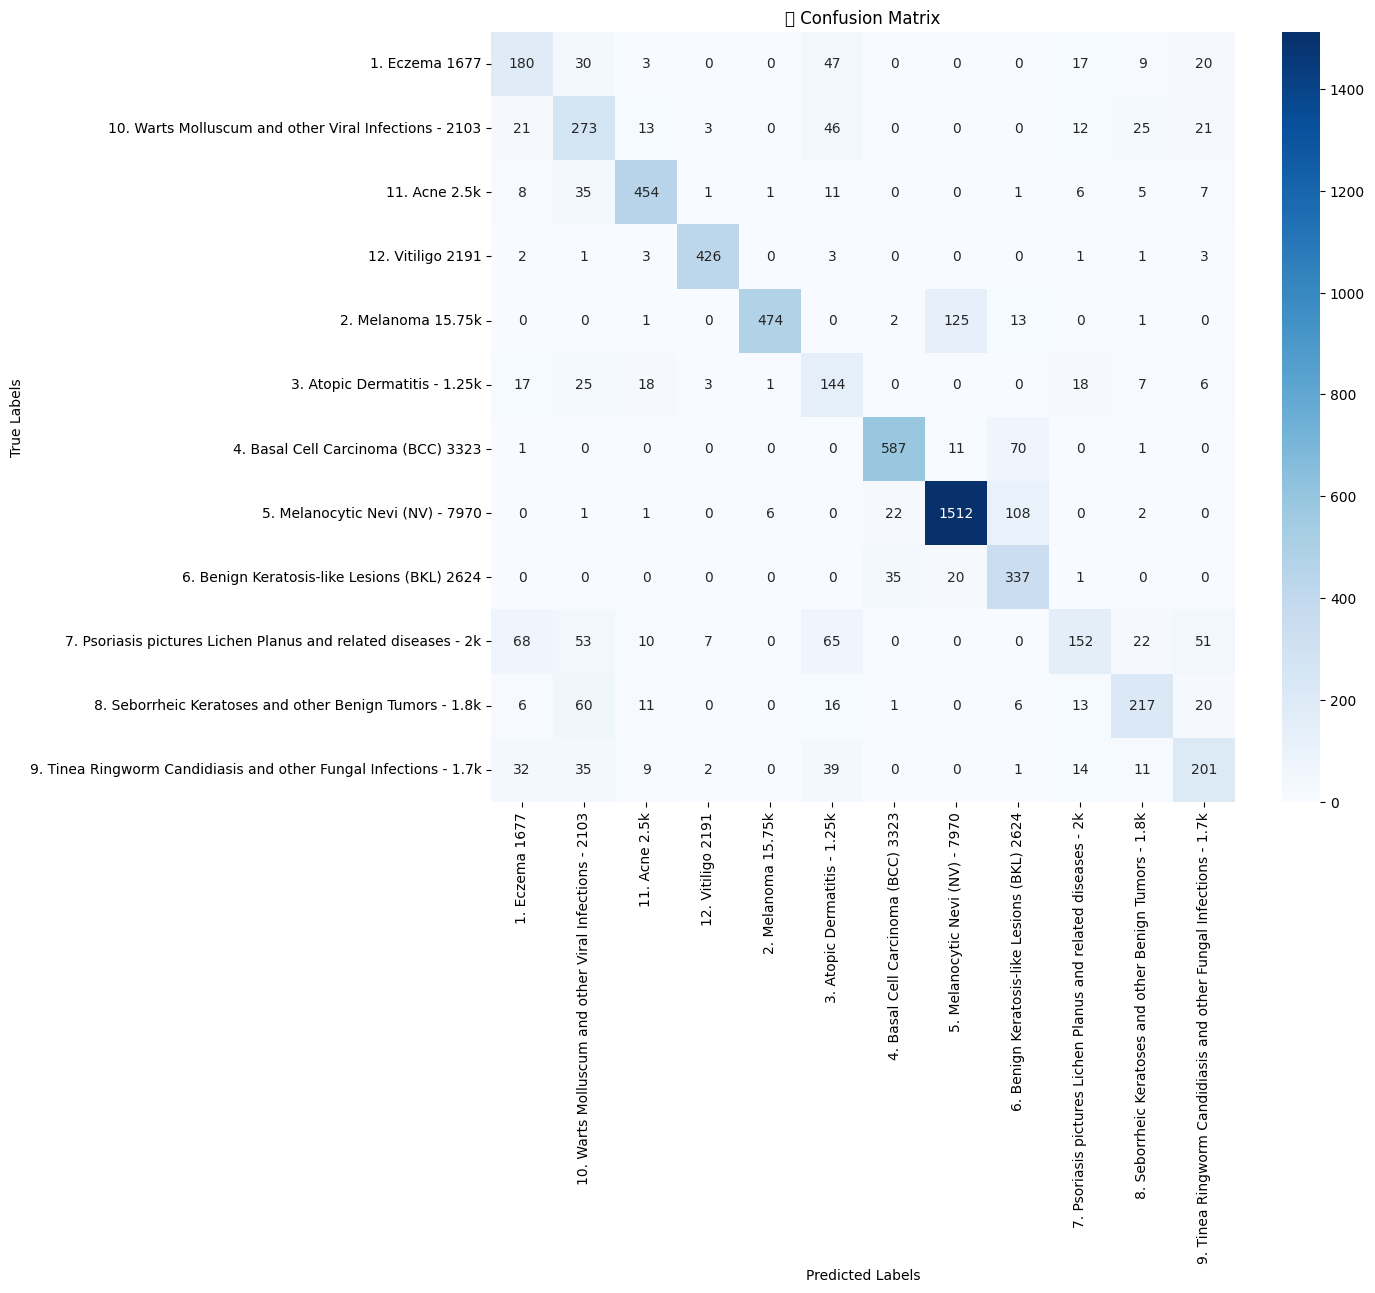

399/399 ━━━━━━━━━━━━━━━━━━━━ 19s 42ms/step


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


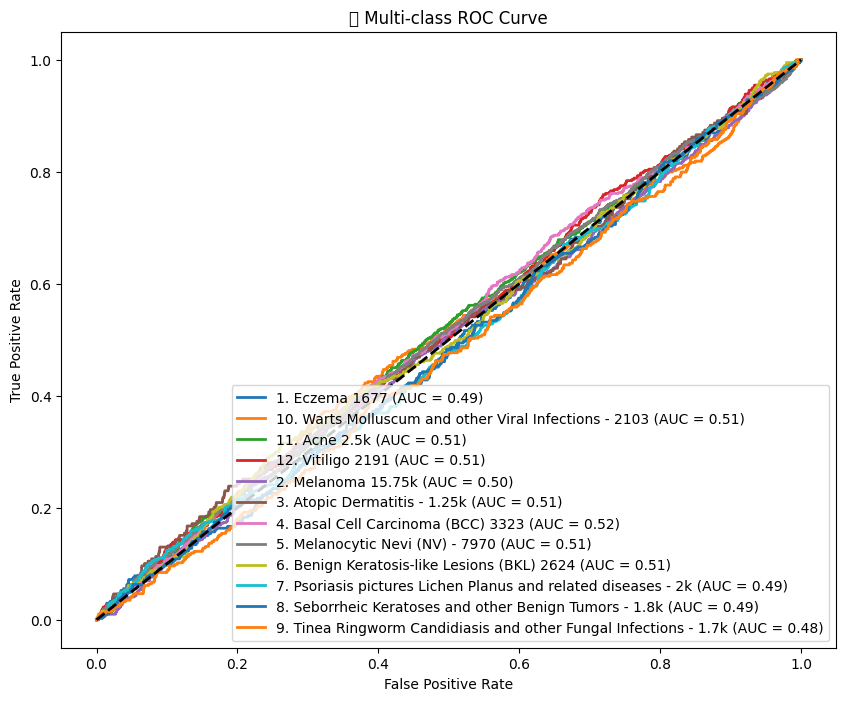

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import tensorflow as tf

# ✅ Step 1: Get predictions and true labels
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# ✅ Step 2: Classification report
print("📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ✅ Step 3: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title("🧩 Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# ✅ Step 4: Plot training curves (accuracy and loss)
def plot_training_curves(history):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.title("📈 Accuracy Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title("📉 Loss Over Epochs")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()

# If you trained in 2 phases:
# plot_training_curves(history1)
# plot_training_curves(history2)

# Or for single-phase:
# plot_training_curves(history)

# ✅ Step 5 (Optional): Multi-class ROC Curve
try:
    # Convert labels to one-hot encoding
    y_true_bin = label_binarize(y_true, classes=list(range(len(class_names))))
    preds = model.predict(val_ds)
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], preds[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    
    # Plot ROC Curves
    plt.figure(figsize=(10, 8))
    colors = cycle(plt.cm.tab10.colors)
    for i, color in zip(range(len(class_names)), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("📊 Multi-class ROC Curve")
    plt.legend(loc="lower right")
    plt.show()
except Exception as e:
    print(f"⚠️ ROC curve skipped: {e}")


In [13]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━